# Cross-Mode Skill Generalization

### 1. Objective

This analysis investigates whether the Skill Index derived from Solo gameplay
generalizes to team-based modes.

Specifically, we aim to:

1. Compute win rate for Duos, Trios, and Squads
2. Examine correlation between SkillIndex and team-mode success
3. Visualize relationships across modes
4. Evaluate predictive power through regression models

### 2. Import Required Libraries

We maintain the same visualization configuration to ensure
consistency across the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_style("whitegrid")

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
})

### 3. Data Preparation

We reconstruct the Solo Skill Index and compute win rates
for all team-based modes.

In [2]:
df = pd.read_csv("../data/Fortnite_players_stats.csv")

df = df[df["Solo matches"] >= 50].copy()

df["Solo_kpm"] = df["Solo kills"] / df["Solo matches"]
df["Solo_mpm"] = df["Solo minutesPlayed"] / df["Solo matches"]
df["Solo_wr"] = df["Solo top1"] / df["Solo matches"]

df["Duos_wr"] = df["Duos top1"] / df["Duos matches"]
df["Trios_wr"] = df["Trios top1"] / df["Trios matches"]
df["Squads_wr"] = df["Squads top1"] / df["Squads matches"]

### 4. Reconstruct PCA-Based Skill Index

The Skill Index is defined as the first principal component
derived from Solo behavioral variables.

In [3]:
features = ["Solo kd", "Solo_kpm", "Solo_mpm"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

df["SkillIndex"] = X_pca[:,0]

### 5. Skill Transfer Across Modes

We compute correlation between Solo SkillIndex
and win rate in team modes.

In [4]:
corr_duos = np.corrcoef(df["SkillIndex"], df["Duos_wr"])[0,1]
corr_trios = np.corrcoef(df["SkillIndex"], df["Trios_wr"])[0,1]
corr_squads = np.corrcoef(df["SkillIndex"], df["Squads_wr"])[0,1]

corr_duos, corr_trios, corr_squads

(np.float64(0.6004442288976665), np.float64(nan), np.float64(nan))

### 6. Visualization of Cross-Mode Relationships

Scatter plots illustrate how Solo skill relates
to performance in team-based modes.

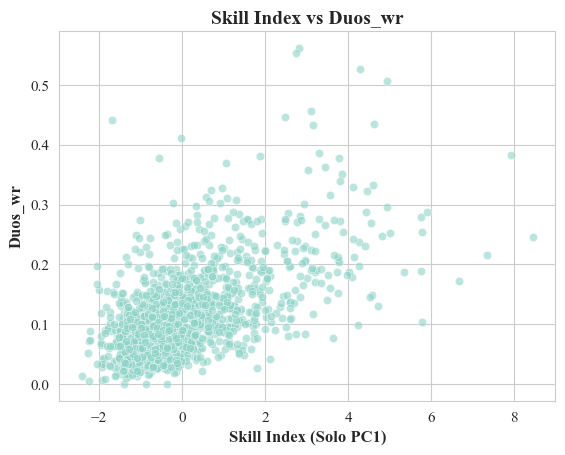

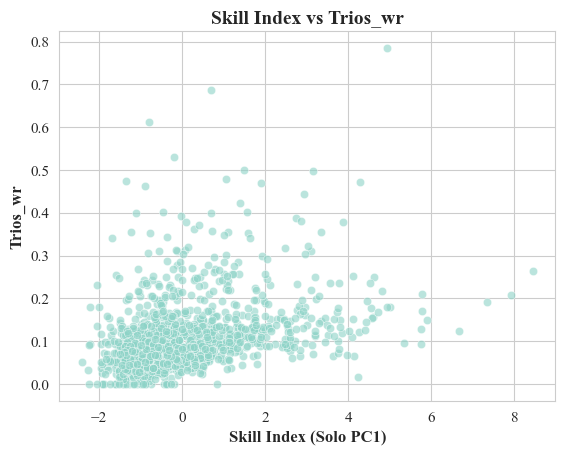

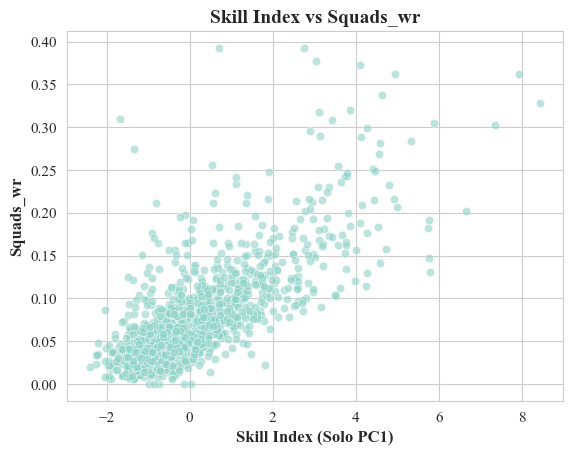

In [5]:
modes = ["Duos_wr", "Trios_wr", "Squads_wr"]

for mode in modes:

    plt.figure()

    sns.scatterplot(
        x=df["SkillIndex"],
        y=df[mode],
        alpha=0.6
    )

    plt.xlabel("Skill Index (Solo PC1)")
    plt.ylabel(mode)
    plt.title(f"Skill Index vs {mode}")

    plt.show()

### 7. Regression-Based Evaluation

We estimate linear regression models to quantify
how well Solo skill predicts success in other modes.

In [6]:
results = {}

for mode in modes:

    temp = df[["SkillIndex", mode]].dropna()

    model = LinearRegression()

    X = temp[["SkillIndex"]]
    y = temp[mode]

    model.fit(X, y)

    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)

    results[mode] = r2

results

{'Duos_wr': 0.3605332720165133,
 'Trios_wr': 0.14401720926270012,
 'Squads_wr': 0.5839060416449511}

### 8. Conclusions

1. The Solo-derived Skill Index demonstrates measurable transferability
   to team-based game modes, though the strength of this relationship varies.

2. Regression results indicate different explanatory power across modes:

   - Duos: R² ≈ 0.36
   - Trios: R² ≈ 0.14
   - Squads: R² ≈ 0.58

3. The strongest relationship appears in Squads mode, suggesting that
   individual combat efficiency still plays a substantial role even in
   larger team environments.

4. The relatively weak explanatory power in Trios indicates that
   team coordination and group dynamics may dominate over individual skill.

5. These results suggest that while individual combat efficiency is a
   transferable component of player performance, team-based success is
   influenced by additional factors beyond individual skill.

Overall, the Solo-based Skill Index captures an important dimension of player ability,
but team modes introduce structural complexity that reduces the predictive power
of individual performance metrics.